In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
# sys.path.append('../../../')
# from mount_drive import mount_s_drive

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from sklearn.datasets import make_classification


2025-12-24 18:22:27.381288: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-24 18:22:28.174385: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-24 18:22:34.383381: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer
from PMAPUtil import *
from sklearn.decomposition import PCA

In [4]:
columns = [
    # Demographics
    "gender",
    "age",

    # Neurologic
    "first_mGCS",
    "flo_first_r_cpn_glasgow_coma_scale_score",

    # Vital Signs – First
    "flo_first_bp_systolic",
    "flo_first_bp_diastolic",
    "flo_first_r_map",
    "flo_first_temperature",
    "flo_first_r_ed_pre-arrival_pulse_(heart_rate)",
    "flo_first_r_fio2",
    "flo_first_r_spo2:fio2_covid-19_calculation",

    # Severity Scores
    "flo_first_r_sofa_score",

    "flo_first_r_jhm_ip_sofa_cv_score",
    "flo_first_r_jhm_ip_sofa_cns_score",
    "flo_first_r_jhm_ip_sofa_coagulation_score",
    "flo_first_r_jhm_ip_sofa_liver_score",
    "flo_first_r_jhm_ip_sofa_renal_score",
    
    # Respiratory / Oxygenation
    "flo_first_r_jhm_ip_pao2/fio2",
    "flo_first_r_jhm_ip_rt_vent_fio2_(%)",
    "flo_first_r_jhm_ip_rt_conv._vent._high_respiratory_rate",
    "flo_first_r_jhm_ip_rt_conv._vent._low_respiratory_rate",

    # Hemodynamics / Shock
    "flo_first_r_norepinephrine_volume",

    # Renal / Urine Output
    "flo_first_jhm_ip_4hr_urine_output_goal_(12ml/kg)_is_at_least",
    "flo_first_jhm_ip_4hr_urine_output_goal_(2ml/kg)_is_at_least",

    # Anthropometrics
    "flo_first_r_bmi",

    # Labs – First
    "lab_first_troponin",
    "lab_first_creatinine,whole_blood",
    "lab_first_lactate",
    "lab_first_glucose,whole_blood",
    "lab_first_potassium,whole_blood",
    "lab_first_sodium,whole_blood",
    "lab_first_hemoglobin,total,whole_blood",
    "lab_first_aptt",

    'hypothermia'
]


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
# death_at_disch hypothermia 
def getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', aTreatmentColumn = 'hypothermia', aTestSize = 0.3, aTreatmentSplit = False, aDropColumns = [], aSkipTemp = True):
    myPredictorsDf = pd.read_csv('PMAP_Predictors2.csv')

    # top_corr = pd.read_csv('top_correlations.csv')
    columns_to_drop = []#top_corr[top_corr['hypothermia'].abs() > 0.7]['Unnamed: 0'].tolist()
    
    # Preprocessing
    myFilter = (myPredictorsDf['first_mGCS_time'] != myPredictorsDf['last_mGCS_time']) 
    myPredictorsDf.loc[myPredictorsDf['death_at_disch'] == 1, 'last_mGCS'] = 1
    myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'last_mGCS'].astype(float) == 6).astype(int)

    myBinaryColumns = myPredictorsDf.columns[myPredictorsDf.nunique() == 2] 
    myBinaryDf = myPredictorsDf[myBinaryColumns]
    myBinaryDf = myBinaryDf.select_dtypes(exclude=["object"])
    myLowColumns = myBinaryDf.columns[(myBinaryDf.sum() < 15)]
    myPredictorsDf.drop(columns=list(myLowColumns) + aDropColumns, inplace=True)

    myGcs15Fitler = (myPredictorsDf.first_mGCS != 6)

    if (aPredictedColumn == 'LastMGCSPositive'):
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & myFilter & ~myPredictorsDf[aTreatmentColumn].isna()]
    else:
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & ~myPredictorsDf[aPredictedColumn].isna() & ~myPredictorsDf[aTreatmentColumn].isna()]

    myColumns = []
    if (aSkipTemp):
        myColumns = [x for x in myPredictorsDf.columns if 'emp' in x.lower() or 'dx_' == x[0:3] ]

    # Get output data
    myXValue = myPredictorsDf.drop(columns=columns_to_drop+  myColumns + ['first_mGCS', 'last_mGCS_time', 'first_mGCS_time', 'LastMGCSPositive', 'last_mGCS', 'death_at_disch'])
    myXValue = myXValue
    myXValue = myXValue.select_dtypes(exclude=['object'])
    myYValue = myPredictorsDf[aPredictedColumn]
    myYValue = myYValue.astype(int)

    if (aTreatmentSplit):
        myXValue = myXValue.drop(columns=[aTreatmentColumn])
        X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(myXValue, myPredictorsDf[aTreatmentColumn], myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, T_train, T_test, y_train, y_test
    else:
        X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, y_train, y_test

In [30]:
myTreatmentColumn = 'hypothermia'
myPredictorsDf, X_train, X_test, y_train, y_test = getTrainTestFunctions(aPredictedColumn = 'death_at_disch', 
                                                                         aTreatmentColumn = myTreatmentColumn, 
                                                                         aSkipTemp = False) 

In [31]:
columns_filter = np.unique([x for x in columns if x in X_test.columns])

X_train = X_train[columns_filter]
X_test = X_test[columns_filter]

In [32]:
def getCovariatePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = PCA(0.99)
        )

def getVariancePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = VarianceThreshold(0.01)
        )

In [33]:
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=50)
    myImputer.set_output(transform="pandas")
    myBinaryColumns  = ['bin__' + x for x in myBinaryColumns]
    # myCovariates = getCovariatePreprocessor(['keep__bin__' + myTreatmentColumn])
    # myCovariates.set_output(transform="pandas")
    # myVariance = getVariancePreprocessor(['bin__' + myTreatmentColumn])
    # myVariance.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor), ('imputer', myImputer)]

In [34]:
# X_train = X_train.loc[:, X_train.isnull().mean() < 0.9]
# X_test = X_test[X_train.columns]

In [35]:
# [x for x in X_train.columns if 'death' in x.lower()]

In [36]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train))
X_train_transf = myPipeline.fit_transform(X_train, y_train)
X_test_transf = myPipeline.transform(X_test)
X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())

In [37]:
X_test_transf.columns

Index(['num__age', 'num__flo_first_bp_diastolic', 'num__flo_first_bp_systolic',
       'num__flo_first_jhm_ip_4hr_urine_output_goal_(12ml/kg)_is_at_least',
       'num__flo_first_jhm_ip_4hr_urine_output_goal_(2ml/kg)_is_at_least',
       'num__flo_first_r_bmi', 'num__flo_first_r_cpn_glasgow_coma_scale_score',
       'num__flo_first_r_ed_pre-arrival_pulse_(heart_rate)',
       'num__flo_first_r_fio2', 'num__flo_first_r_jhm_ip_pao2/fio2',
       'num__flo_first_r_jhm_ip_rt_conv._vent._high_respiratory_rate',
       'num__flo_first_r_jhm_ip_rt_conv._vent._low_respiratory_rate',
       'num__flo_first_r_jhm_ip_rt_vent_fio2_(%)', 'num__flo_first_r_map',
       'num__flo_first_r_norepinephrine_volume', 'num__flo_first_r_sofa_score',
       'num__flo_first_r_spo2:fio2_covid-19_calculation',
       'num__flo_first_temperature', 'num__lab_first_aptt',
       'num__lab_first_creatinine,whole_blood',
       'num__lab_first_glucose,whole_blood',
       'num__lab_first_hemoglobin,total,whole_blood'

In [38]:
import torch
import torch.nn as nn

class MLPBinary(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(32, 1)  # logits (no sigmoid here)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)  # (batch,)


    @torch.no_grad()
    def predict_proba(self, X, device=None, batch_size=8192):
        """
        sklearn-style: returns shape (n, 2) = [P(class0), P(class1)]
        """
        self.eval()
        device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.to(device)

        # X can be numpy or pandas
        if hasattr(X, "to_numpy"):
            X = X.to_numpy()
        X = np.asarray(X, dtype=np.float32)

        probs1 = []
        for i in range(0, len(X), batch_size):
            xb = torch.from_numpy(X[i:i+batch_size]).to(device)
            logits = self(xb)
            p1 = torch.sigmoid(logits).detach().cpu().numpy()
            probs1.append(p1)

        p1 = np.concatenate(probs1, axis=0).reshape(-1)
        p0 = 1.0 - p1
        return np.stack([p0, p1], axis=1)

    @torch.no_grad()
    def predict(self, X, threshold=0.5, **kwargs):
        """
        sklearn-style: returns class labels (0/1)
        """
        proba = self.predict_proba(X, **kwargs)[:, 1]
        return (proba >= threshold).astype(int)


In [39]:
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score

def to_tensor(x):
    # works if x is numpy array or pandas dataframe
    if hasattr(x, "to_numpy"):
        x = x.to_numpy()
    return torch.tensor(x, dtype=torch.float32)

def train_mlp(
    X_train, y_train,
    X_val, y_val,
    epochs=15,
    batch_size=32,
    lr=1e-3,
    weight_decay=0.0,
    device=None,
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    # Ensure y is shape (N,) float32 in {0,1}
    y_train_np = y_train.to_numpy().reshape(-1) if hasattr(y_train, "to_numpy") else np.asarray(y_train).reshape(-1)
    y_val_np   = y_val.to_numpy().reshape(-1) if hasattr(y_val, "to_numpy") else np.asarray(y_val).reshape(-1)

    X_train_t = to_tensor(X_train)
    y_train_t = torch.tensor(y_train_np, dtype=torch.float32)
    X_val_t   = to_tensor(X_val)
    y_val_t   = torch.tensor(y_val_np, dtype=torch.float32)

    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True, drop_last=False)

    model = MLPBinary(input_dim=X_train_t.shape[1]).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    for epoch in range(1, epochs + 1):
        # ---- train ----
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)                  # (batch,)
            loss = criterion(logits, yb)        # BCE with logits
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        # ---- validate ----
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t.to(device)).detach().cpu().numpy()
            val_probs = 1 / (1 + np.exp(-val_logits))  # sigmoid
            val_pred = (val_probs >= 0.5).astype(int)

        val_auc = roc_auc_score(y_val_np, val_probs) if len(np.unique(y_val_np)) == 2 else np.nan
        val_acc = accuracy_score(y_val_np, val_pred)

        print(f"Epoch {epoch:02d}/{epochs} | loss={np.mean(train_losses):.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

    return model


In [40]:
# If your y's are DataFrames with a single column, flatten them:
ytr = y_train.reset_index(drop=True)
yte = y_test.reset_index(drop=True)
if hasattr(ytr, "shape") and len(getattr(ytr, "shape", ())) == 2 and ytr.shape[1] == 1:
    ytr = ytr.iloc[:, 0]
if hasattr(yte, "shape") and len(getattr(yte, "shape", ())) == 2 and yte.shape[1] == 1:
    yte = yte.iloc[:, 0]

model_torch = train_mlp(
    X_train_transf, ytr,
    X_test_transf, yte,
    epochs=20,
    batch_size=32,
    lr=1e-3
)


Epoch 01/20 | loss=0.6638 | val_acc=0.6604 | val_auc=0.6832
Epoch 02/20 | loss=0.6413 | val_acc=0.6604 | val_auc=0.7041
Epoch 03/20 | loss=0.6232 | val_acc=0.6627 | val_auc=0.7100
Epoch 04/20 | loss=0.6037 | val_acc=0.6698 | val_auc=0.7163
Epoch 05/20 | loss=0.5887 | val_acc=0.7241 | val_auc=0.7229
Epoch 06/20 | loss=0.5778 | val_acc=0.7241 | val_auc=0.7255
Epoch 07/20 | loss=0.5672 | val_acc=0.7335 | val_auc=0.7309
Epoch 08/20 | loss=0.5502 | val_acc=0.7264 | val_auc=0.7336
Epoch 09/20 | loss=0.5628 | val_acc=0.7335 | val_auc=0.7373
Epoch 10/20 | loss=0.5492 | val_acc=0.7288 | val_auc=0.7406
Epoch 11/20 | loss=0.5466 | val_acc=0.7264 | val_auc=0.7412
Epoch 12/20 | loss=0.5419 | val_acc=0.7311 | val_auc=0.7419
Epoch 13/20 | loss=0.5273 | val_acc=0.7264 | val_auc=0.7418
Epoch 14/20 | loss=0.5274 | val_acc=0.7217 | val_auc=0.7403
Epoch 15/20 | loss=0.5315 | val_acc=0.7241 | val_auc=0.7396
Epoch 16/20 | loss=0.5400 | val_acc=0.7288 | val_auc=0.7395
Epoch 17/20 | loss=0.5226 | val_acc=0.71

In [41]:
from sklearn.metrics import roc_auc_score

def predict_proba(model, X, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    X_t = to_tensor(X).to(device)
    with torch.no_grad():
        logits = model(X_t).detach().cpu().numpy()
    return 1 / (1 + np.exp(-logits))

def bootstrap_auc_ci(y_true, y_score, n_bootstraps=2000, seed=42):
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true).reshape(-1)
    y_score = np.asarray(y_score).reshape(-1)

    aucs = []
    n = len(y_true)
    for _ in range(n_bootstraps):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_score[idx]))

    aucs = np.asarray(aucs)
    return roc_auc_score(y_true, y_score), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

probs_test = predict_proba(model_torch, X_test_transf)
auc, lo, hi = bootstrap_auc_ci(yte, probs_test)
print(f"Test AUC = {auc:.3f} (95% CI {lo:.3f}–{hi:.3f})")


Test AUC = 0.733 (95% CI 0.679–0.785)


In [23]:
model = keras.Sequential([
    keras.Input(shape=(X_train_transf.shape[1],)),  
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') 
])
# from tensorflow.keras.callbacks import EarlyStopping

# early_stopping = EarlyStopping(
#     monitor='loss',  # Metric to track
#     patience=10,          # Number of epochs to wait before stopping
#     restore_best_weights=True  # Restore the best model weights
# )

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name="roc_auc")])


In [24]:
history = model.fit(X_train_transf, y_train.reset_index().drop(columns='index'), epochs=10, batch_size=8, validation_data=(X_test_transf, y_test.reset_index().drop(columns='index')))#, callbacks=[early_stopping])

Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5995 - loss: 0.7398 - roc_auc: 0.5092 - val_accuracy: 0.7526 - val_loss: 0.5731 - val_roc_auc: 0.6035
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7088 - loss: 0.5840 - roc_auc: 0.6002 - val_accuracy: 0.7577 - val_loss: 0.5489 - val_roc_auc: 0.6408
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7241 - loss: 0.5465 - roc_auc: 0.6446 - val_accuracy: 0.7603 - val_loss: 0.5316 - val_roc_auc: 0.6948
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7560 - loss: 0.5062 - roc_auc: 0.6949 - val_accuracy: 0.7603 - val_loss: 0.5150 - val_roc_auc: 0.7216
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7748 - loss: 0.4501 - roc_auc: 0.7848 - val_accuracy: 0.7603 - val_loss: 0.4959 - val_roc_auc: 0.7590
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7799 - loss: 0.4403 - roc_auc: 0.8023 - val_accuracy: 0.7655 - val_loss: 0.4896 - val_roc_auc:

100%|██████████| 10/10 [00:01<00:00,  6.97it/s]


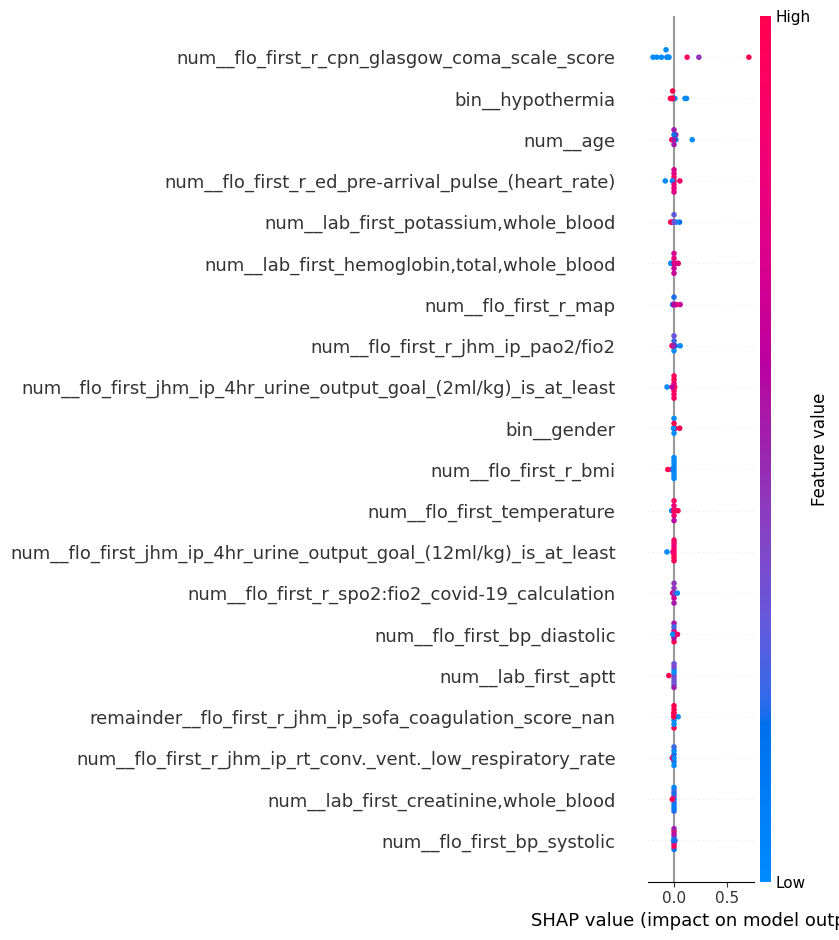

In [23]:
import shap
import numpy as np

# Use a small representative background set
X_background = X_test_transf[:100]
X_explain = X_test_transf[:10]

# shap needs a prediction function that outputs a 2D array
explainer = shap.KernelExplainer(model_torch.predict, X_background)
shap_values = explainer.shap_values(X_explain)

shap.summary_plot(shap_values, X_explain)


In [24]:
# (importance_df['feature'] == feature_name).sum()

In [26]:
import numpy as np
import pandas as pd

# 1. Compute mean absolute SHAP value for each feature
mean_abs_shap = np.abs(shap_values[0]).mean(axis=0)  # shape: (n_features,)

# 2. Create a DataFrame for easy lookup and sorting
importance_df = pd.DataFrame({
    'feature': X_explain.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values(by='mean_abs_shap', ascending=False).reset_index(drop=True)

# 3. Find the rank of a specific feature
feature_name = "bin__hypothermia"  # replace with your actual feature
rank = importance_df.index[importance_df['feature'] == feature_name].item() + 1
score = importance_df.loc[importance_df['feature'] == feature_name, 'mean_abs_shap'].item()

print(f"🔍 Feature '{feature_name}' is ranked #{rank} out of {X_explain.shape[1]} in importance with mean(|SHAP|) = {score:.4f}")


🔍 Feature 'bin__hypothermia' is ranked #27 out of 55 in importance with mean(|SHAP|) = 0.0027


In [27]:
shap.plots.bar(shap_values)


TypeError: The shap_values argument must be an Explanation object, Cohorts object, or dictionary of Explanation objects!

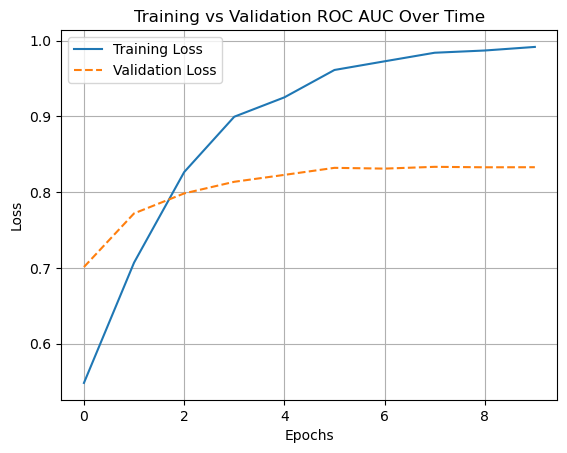

In [56]:
# Extract loss values
train_loss = history.history['roc_auc']
val_loss = history.history['val_roc_auc']

# Plot training & validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss', linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation ROC AUC Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
y_pred_probs = model.predict(X_test_transf)  # Probabilities

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
ROC AUC Score: 0.8100


In [58]:
import numpy as np
from sklearn.metrics import roc_auc_score

def bootstrap_auc_ci(y_true, y_pred_proba, n_bootstraps=1000, ci=95, random_seed=42):
    rng = np.random.RandomState(random_seed)
    n = len(y_true)
    bootstrapped_scores = []
    
    for _ in range(n_bootstraps):
        # Sample with replacement
        indices = rng.choice(np.arange(n), size=n, replace=True)
        if len(np.unique(y_true[indices])) < 2:
            # We need at least one positive and one negative sample
            continue
        score = roc_auc_score(y_true[indices], y_pred_proba[indices])
        bootstrapped_scores.append(score)
    
    sorted_scores = np.sort(bootstrapped_scores)
    lower_bound = np.percentile(sorted_scores, (100 - ci) / 2)
    upper_bound = np.percentile(sorted_scores, 100 - (100 - ci) / 2)
    
    return lower_bound, upper_bound, sorted_scores

# Example usage
# y_true = np.array([...])
# y_pred_proba = np.array([...])

ci_lower, ci_upper, auc_scores = bootstrap_auc_ci(y_test.to_numpy(), y_pred_probs)
print(f"95% CI for AUC: [{ci_lower:.3f}, {ci_upper:.3f}]")


95% CI for AUC: [0.782, 0.875]


In [42]:
myX = pd.concat([X_train_transf.reset_index().drop(columns='index'), X_test_transf.reset_index().drop(columns='index')])
myY = pd.concat([y_train.reset_index().drop(columns='index'), y_test.reset_index().drop(columns='index')])

Optimization terminated successfully.
         Current function value: 0.540451
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.540121
         Iterations 6
Likelihood ratio of test results:
Chi square statistic: 0.8520268201841645
p-value: 0.3559795918398032
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                 1289
Model:                          Logit   Df Residuals:                     1286
Method:                           MLE   Df Model:                            2
Date:                Wed, 24 Dec 2025   Pseudo R-squ.:                 0.02962
Time:                        18:26:10   Log-Likelihood:                -696.64
converged:                       True   LL-Null:                       -717.90
Covariance Type:            nonrobust   LLR p-value:                 5.840e-10
                      

np.float64(0.3559795918398032)

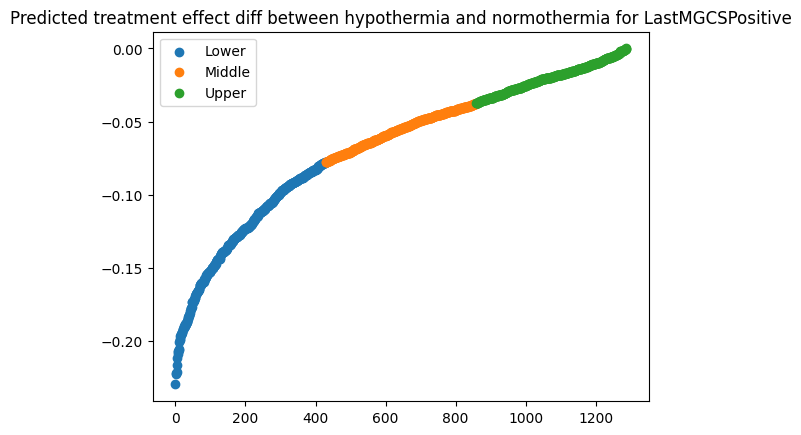

In [29]:
getTreatmentEffectDiff(aX = myX.reset_index().drop(columns='index'), aY = myY.reset_index().drop(columns='index'), aModel = model_torch, \
                       aCategory = 'LastMGCSPositive', aGroup = 'bin__hypothermia', aUseNeuralNetwork = True, aByGroup = False)

In [43]:
getTreatmentEffectDiff(aX = X_train_transf.reset_index().drop(columns='index'), aY = y_train.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'death_at_disch', aGroup = 'bin__hypothermia', aUseNeuralNetwork = True, aByGroup = False)

NameError: name 'model' is not defined